# 07 — DOS, PDOS and OPDOS analysis

Compare absolute-energy, HOMO-aligned, atom-normalized, projected, and overlap-population density-of-states results.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make figures independent of PyCharm/Jupyter dark-theme defaults.
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
    }
)


def style_white_axes(fig, ax):
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.tick_params(colors="black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.title.set_color("black")
    for spine in ax.spines.values():
        spine.set_edgecolor("black")
    legend = ax.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_color("black")


ROOT = Path("..").resolve()
RESULTS = ROOT / "results" / "ground_state"
FIGURES = ROOT / "figures"
SYSTEM_ORDER = ["pdi", "pdi_terminal_functionalized"]
SYSTEM_LABELS = {
    "pdi": "Parent PDI",
    "pdi_terminal_functionalized": "Terminal-functionalized PDI",
}

In [2]:
dos_curves = pd.read_csv(RESULTS / "dos" / "dos_curves.csv")
dos_lines = pd.read_csv(RESULTS / "dos" / "dos_lines.csv")
orbitals = pd.read_csv(RESULTS / "orbitals" / "frontier_orbital_energies.csv")

DOS_FIGURES = FIGURES / "dos"
DOS_FIGURES.mkdir(parents=True, exist_ok=True)

display(dos_curves.head())


,system,source_file,energy_ev,tdos,opdos,pdos_fragment_1,pdos_fragment_2,pdos_fragment_3,pdos_fragment_4,pdos_fragment_5,pdos_fragment_6,pdos_fragment_7,pdos_fragment_8,pdos_fragment_9,pdos_fragment_10
0,pdi,calculations/pdi/multiwfn_analysis/dos/pdi_dos...,-12.00000,0.000471,0.0,0.000404,0.000016,0.000017,0.000033,0.0,0.0,0.0,0.0,0.0,0.0
1,pdi,calculations/pdi/multiwfn_analysis/dos/pdi_dos...,-11.99466,0.000401,0.0,0.000344,0.000014,0.000015,0.000028,0.0,0.0,0.0,0.0,0.0,0.0
2,pdi,calculations/pdi/multiwfn_analysis/dos/pdi_dos...,-11.98933,0.000341,0.0,0.000293,0.000012,0.000013,0.000024,0.0,0.0,0.0,0.0,0.0,0.0
3,pdi,calculations/pdi/multiwfn_analysis/dos/pdi_dos...,-11.98399,0.000289,0.0,0.000249,0.000010,0.000011,0.000020,0.0,0.0,0.0,0.0,0.0,0.0
4,pdi,calculations/pdi/multiwfn_analysis/dos/pdi_dos...,-11.97866,0.000245,0.0,0.000211,0.000008,0.000009,0.000017,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
required = {"system", "energy_ev", "tdos"}
missing = required - set(dos_curves.columns)

assert not missing, f"Missing columns: {sorted(missing)}"
assert set(dos_curves["system"]) == set(SYSTEM_ORDER)

dos_curves.groupby("system")["energy_ev"].agg(["min", "max", "count"])


,min,max,count
system,,,
pdi,-12.0,4.0,3000
pdi_terminal_functionalized,-12.0,4.0,3000


In [4]:
FRAGMENT_LABELS = {
    "pdos_fragment_1": "C",
    "pdos_fragment_2": "N",
    "pdos_fragment_3": "O",
    "pdos_fragment_4": "H",
}

active = [
    column
    for column in FRAGMENT_LABELS
    if column in dos_curves.columns
    and not np.allclose(dos_curves[column].fillna(0).to_numpy(), 0)
]

homo = orbitals.set_index("system")["homo_energy_ev"].to_dict()
atom_counts = {
    "pdi": 40,
    "pdi_terminal_functionalized": 70,
}

dos = dos_curves.copy()
dos["energy_homo_aligned_ev"] = dos["energy_ev"] - dos["system"].map(homo)
dos["tdos_per_atom"] = dos["tdos"] / dos["system"].map(atom_counts)

for column in active:
    dos[f"{column}_per_atom"] = dos[column] / dos["system"].map(atom_counts)

active


['pdos_fragment_1', 'pdos_fragment_2', 'pdos_fragment_3', 'pdos_fragment_4']

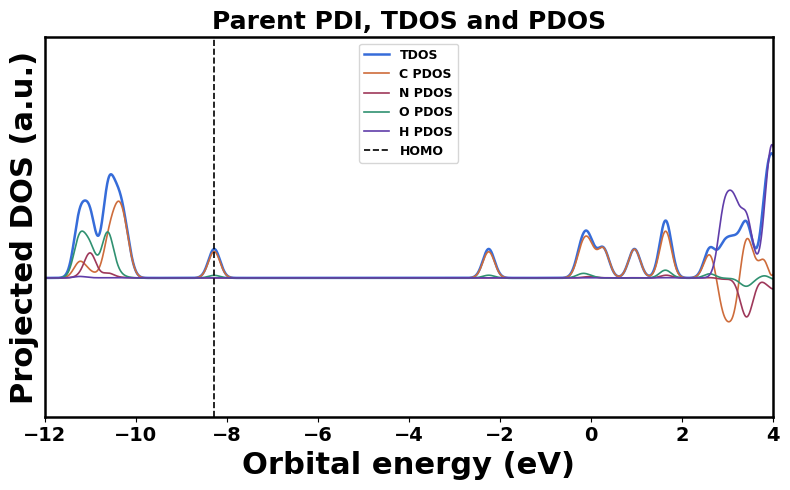

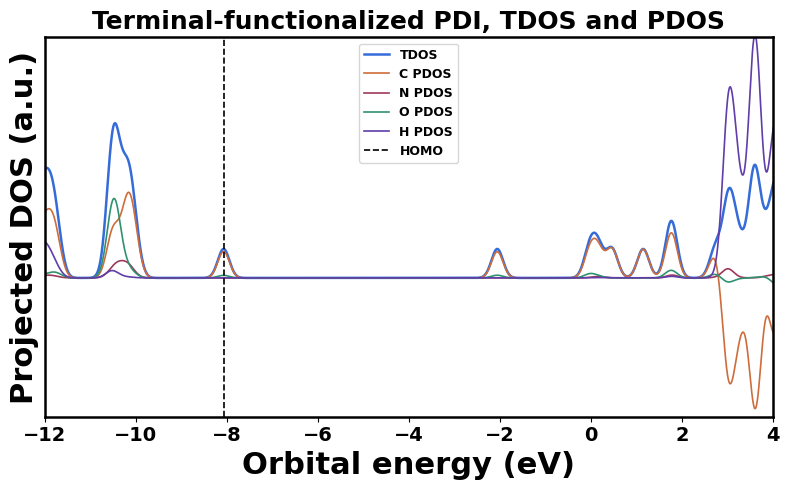

In [5]:
for system in SYSTEM_ORDER:
    data = dos[dos["system"] == system].sort_values("energy_ev")

    fig, ax = plt.subplots(facecolor="white", figsize=(8, 5))
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontsize(14)
        tick_label.set_fontweight("bold")

    ax.plot(
        data["energy_ev"],
        data["tdos"],
        linewidth=1.8,
        label="TDOS",
    )

    for column in active:
        ax.plot(
            data["energy_ev"],
            data[column],
            linewidth=1.2,
            label=f"{FRAGMENT_LABELS[column]} PDOS",
        )

    ax.axvline(
        homo[system],
        color="black",
        linestyle="dashed",
        linewidth=1.2,
        label="HOMO",
    )
    ax.set_xlabel("Orbital energy (eV)", fontsize=22, fontweight="bold")
    ax.set_ylabel("Projected DOS (a.u.)", fontsize=22, fontweight="bold")
    ax.set_title(f"{SYSTEM_LABELS[system]}, TDOS and PDOS", fontsize=18, fontweight="bold")
    ax.legend(frameon=True, prop={"size":9, "weight":"bold"}, loc="upper center")
    #ax.spines[["top", "right"]].set_visible(False)
    style_white_axes(fig, ax)

    ax.set_yticks([])

    ax.set_xlim(-12.0, 4.0)
    ax.set_ylim(-1.5, 2.6)

    fig.tight_layout()
    fig.savefig(
        DOS_FIGURES / f"{system}_tdos_pdos.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        DOS_FIGURES / f"{system}_tdos_pdos.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


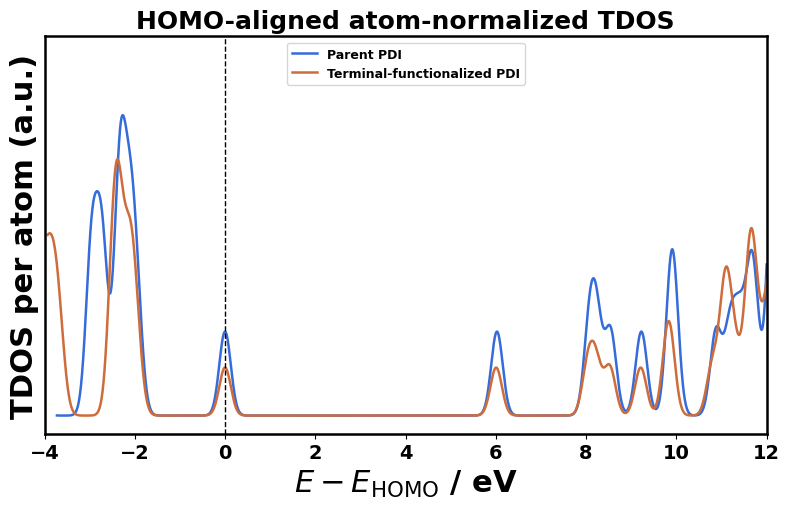

In [6]:
comparison_plots = [
#    (
#        "energy_ev",
#        "tdos",
#        "Absolute-energy TDOS comparison",
#        "tdos_comparison_absolute",
#        "Orbital energy / eV",
#    ),
#    (
#       "energy_homo_aligned_ev",
#        "tdos",
#        "HOMO-aligned TDOS comparison",
#        "tdos_comparison_homo_aligned",
#        r"$E-E_\mathrm{HOMO}$ / eV",
#    ),
    (
        "energy_homo_aligned_ev",
        "tdos_per_atom",
        "HOMO-aligned atom-normalized TDOS",
        "tdos_comparison_homo_aligned_per_atom",
        r"$E-E_\mathrm{HOMO}$ / eV",
    ),
]

for x_column, y_column, title, filename, xlabel in comparison_plots:
    fig, ax = plt.subplots(facecolor="white", figsize=(8.0, 5.2))
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

    for system in SYSTEM_ORDER:
        data = dos[dos["system"] == system].sort_values(x_column)
        ax.plot(
            data[x_column],
            data[y_column],
            linewidth=1.8,
            label=SYSTEM_LABELS[system],
        )

    if "homo_aligned" in x_column:
        ax.axvline(0, color="black", linestyle="dashed", linewidth=1.0)

    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontsize(14)
        tick_label.set_fontweight("bold")

    ylabel = (
        "DOS (a.u.)"
        if y_column == "tdos"
        else "TDOS per atom (a.u.)"
    )
    ax.set_xlabel(xlabel, fontsize=22, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=22, fontweight="bold")
    ax.set_title(title, fontsize=18, fontweight="bold")
    ax.legend(frameon=True, prop={"size":9, "weight":"bold"}, loc="upper center")
    #ax.spines[["top", "right"]].set_visible(False)
    style_white_axes(fig, ax)

    ax.set_xlim(-4.0, 12.0)

    ax.set_yticks([])

    fig.tight_layout()
    fig.savefig(DOS_FIGURES / f"{filename}.pdf", bbox_inches="tight")
    fig.savefig(
        DOS_FIGURES / f"{filename}.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


In [7]:
dos.to_csv(RESULTS / "dos" / "dos_analysis_ready.csv", index=False)
